In [2]:
"""
问题1：电除尘器入口条件、操作参数与出口浓度关系分析
结合物理机理（多依奇公式）与机器学习方法的融合建模
- 物理机理+数据驱动的智能预测模型
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
import warnings
import pickle
import os

warnings.filterwarnings("ignore")

# 设置中文显示
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

print("=" * 80)
print("问题1：电除尘器除尘效率影响因素分析")
print("物理机理与机器学习融合建模")
print("=" * 80)

问题1：电除尘器除尘效率影响因素分析
物理机理与机器学习融合建模


In [4]:
# ============================
# 1. 数据读取与预处理
# ============================
print("\n步骤1: 数据读取与预处理")
print("-" * 50)

# 读取数据
data_path = r"C:\Users\Administrator\Desktop\数模校赛\题目发布\赛题\2026_A题\Cement_ESP_Data.csv"
df = pd.read_csv(data_path)

print(f"原始数据形状: {df.shape}")

# 删除缺失值并排序
df_clean = df.dropna().copy()
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"])
df_clean = df_clean.sort_values("timestamp").reset_index(drop=True)

# 计算目标变量 Y_t = ln(C_out/C_in)
df_clean["Y_t"] = np.log(df_clean["C_out_mgNm3"] / (df_clean["C_in_gNm3"] * 1000))

print(f"清洗后数据形状: {df_clean.shape}")
print(f"时间跨度: {df_clean['timestamp'].min()} 至 {df_clean['timestamp'].max()}")

# 创建输出目录
output_dir = r"C:\Users\Administrator\Desktop\数模校赛\outputs"
os.makedirs(output_dir, exist_ok=True)


步骤1: 数据读取与预处理
--------------------------------------------------
原始数据形状: (10080, 14)
清洗后数据形状: (10030, 15)
时间跨度: 2024-05-01 00:00:00 至 2024-05-07 23:59:00



步骤2: 数据分布分析
--------------------------------------------------
已保存: 01_数据分布分析.png


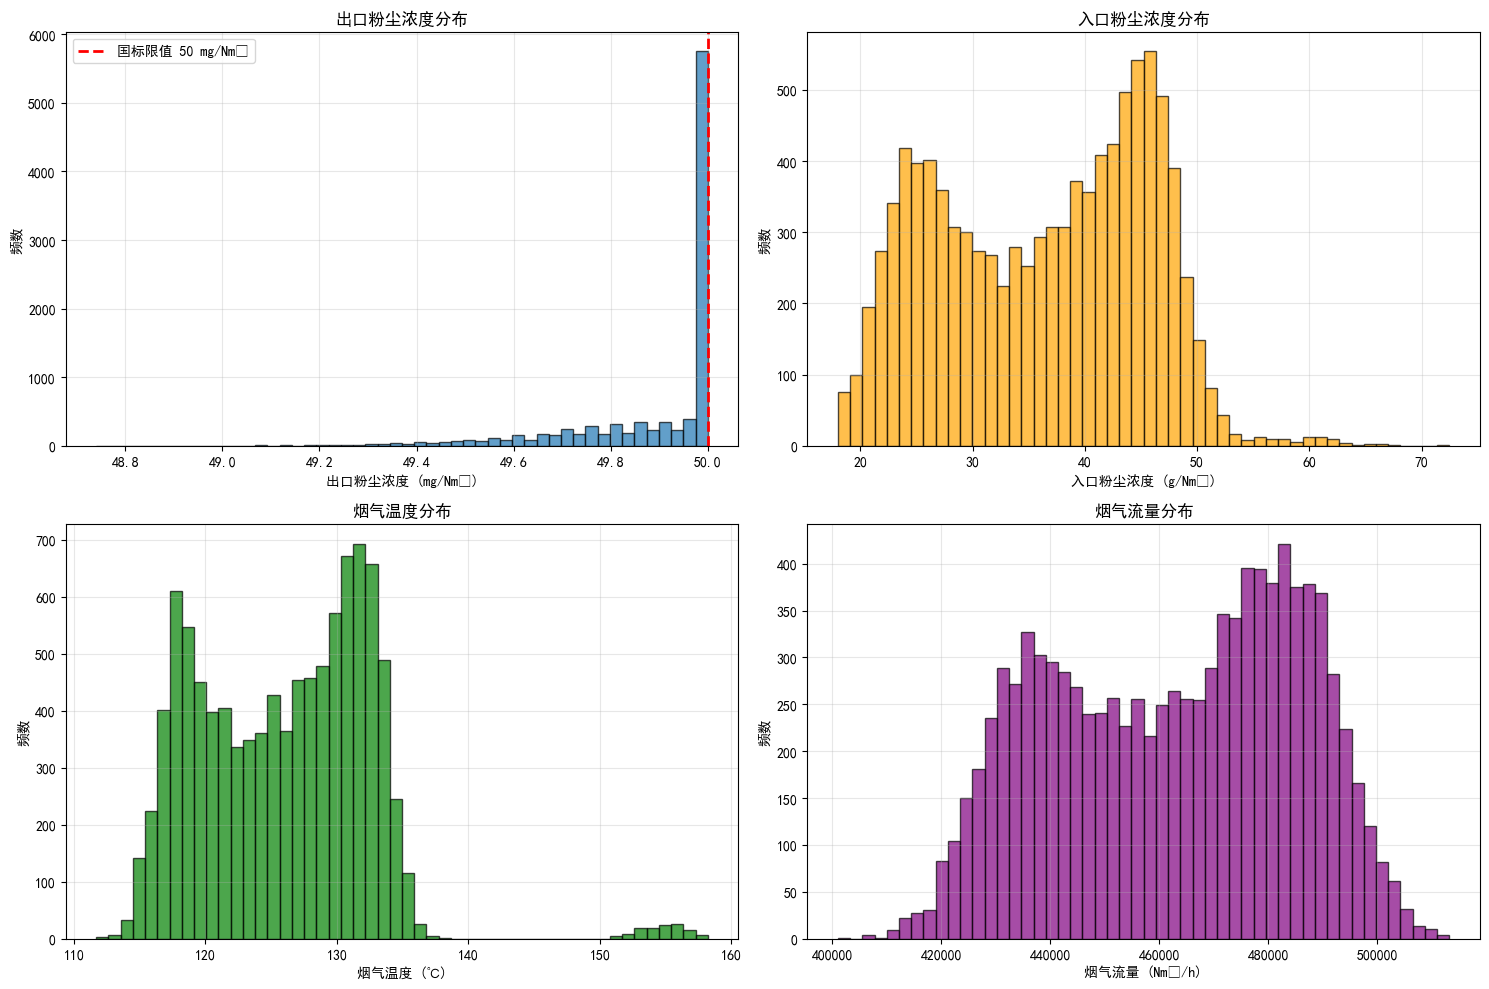

In [11]:
# ============================
# 2. 数据分布可视化
# ============================
print("\n步骤2: 数据分布分析")
print("-" * 50)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 出口浓度分布
axes[0, 0].hist(df_clean["C_out_mgNm3"], bins=50, edgecolor="black", alpha=0.7)
axes[0, 0].axvline(
    50, color="red", linestyle="--", linewidth=2, label="国标限值 50 mg/Nm³"
)
axes[0, 0].set_xlabel("出口粉尘浓度 (mg/Nm³)")
axes[0, 0].set_ylabel("频数")
axes[0, 0].set_title("出口粉尘浓度分布")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 入口浓度分布
axes[0, 1].hist(
    df_clean["C_in_gNm3"], bins=50, edgecolor="black", alpha=0.7, color="orange"
)
axes[0, 1].set_xlabel("入口粉尘浓度 (g/Nm³)")
axes[0, 1].set_ylabel("频数")
axes[0, 1].set_title("入口粉尘浓度分布")
axes[0, 1].grid(alpha=0.3)

# 温度分布
axes[1, 0].hist(
    df_clean["Temp_C"], bins=50, edgecolor="black", alpha=0.7, color="green"
)
axes[1, 0].set_xlabel("烟气温度 (℃)")
axes[1, 0].set_ylabel("频数")
axes[1, 0].set_title("烟气温度分布")
axes[1, 0].grid(alpha=0.3)

# 流量分布
axes[1, 1].hist(
    df_clean["Q_Nm3h"], bins=50, edgecolor="black", alpha=0.7, color="purple"
)
axes[1, 1].set_xlabel("烟气流量 (Nm³/h)")
axes[1, 1].set_ylabel("频数")
axes[1, 1].set_title("烟气流量分布")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/01_数据分布分析.png", dpi=300, bbox_inches="tight")
print(f"已保存: 01_数据分布分析.png")


步骤3: 时间窗口平滑处理
--------------------------------------------------
滚动平均处理完成，窗口大小: 10 分钟
已保存平滑数据: data_smoothed.csv
已保存: 02_平滑效果对比.png


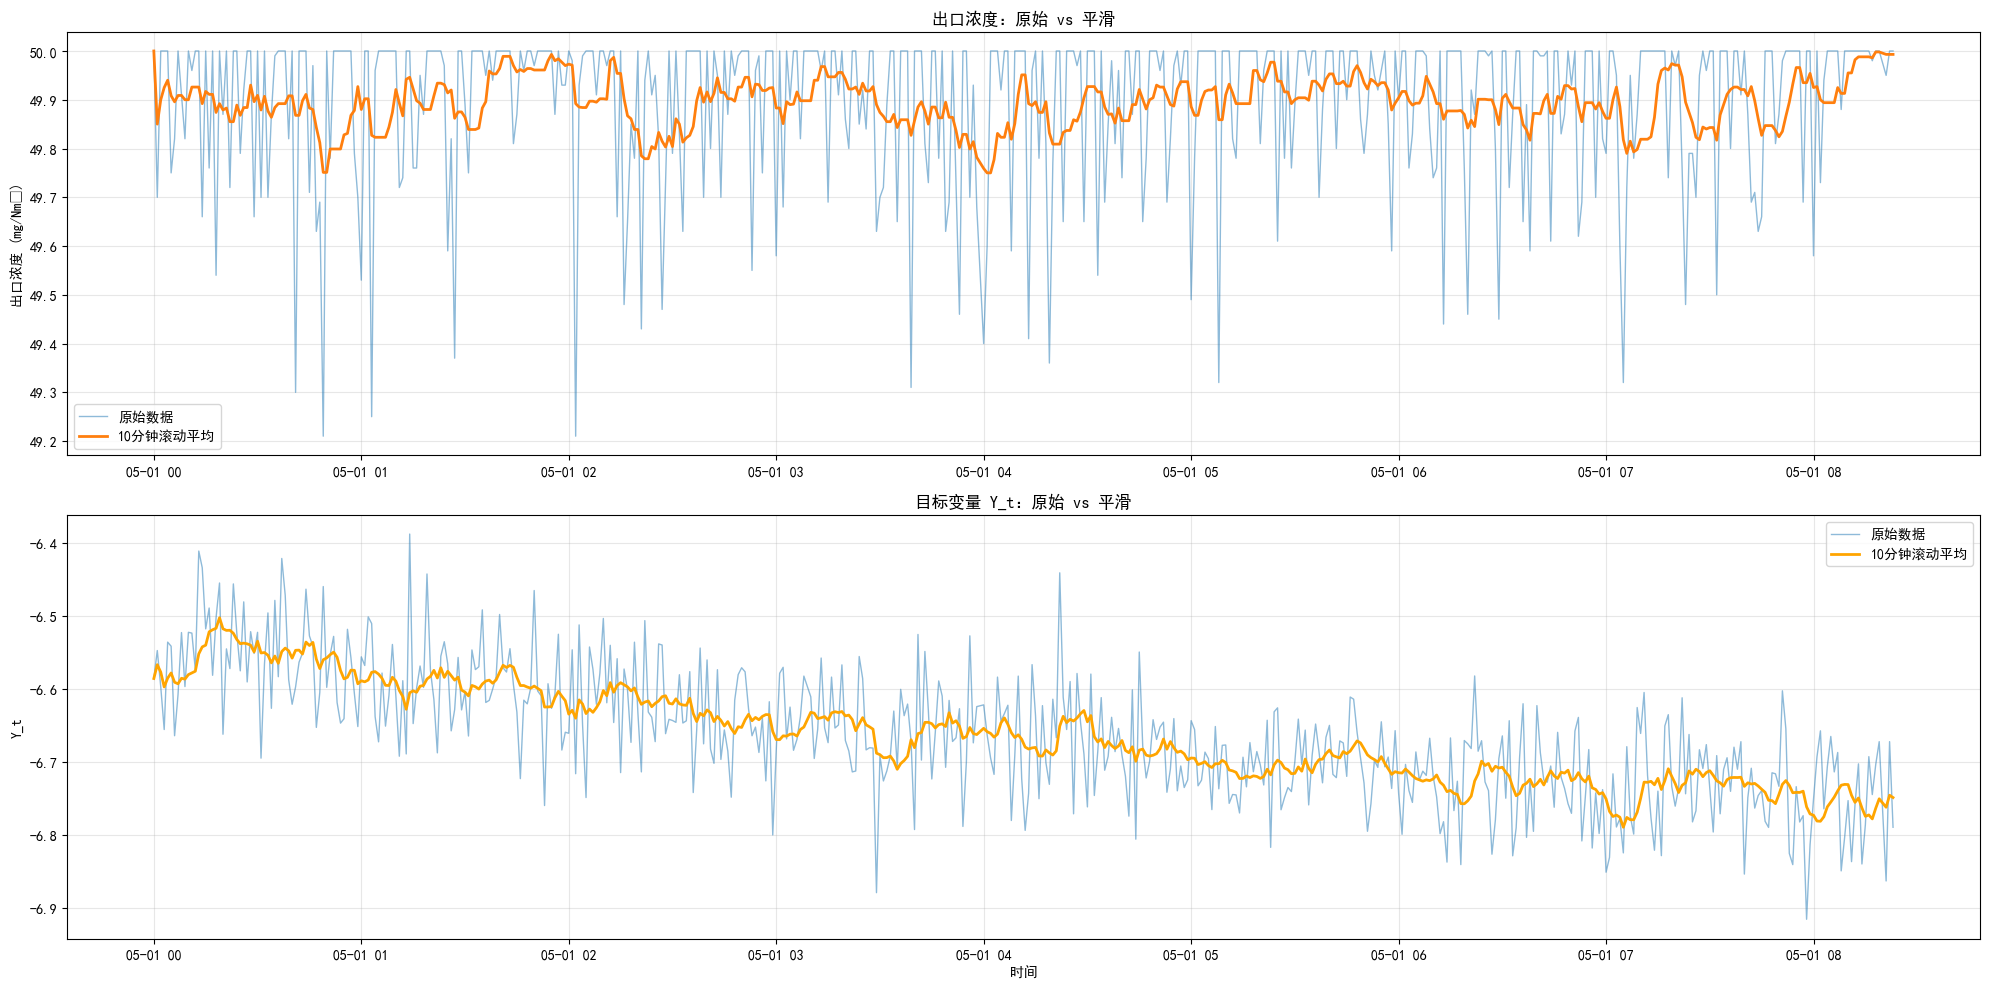

In [6]:
# ============================
# 3. 时间窗口平滑处理
# ============================
print("\n步骤3: 时间窗口平滑处理")
print("-" * 50)

window_size = 10
df_smooth = df_clean.copy()

smooth_cols = [
    "Temp_C",
    "C_in_gNm3",
    "Q_Nm3h",
    "C_out_mgNm3",
    "U1_kV",
    "U2_kV",
    "U3_kV",
    "U4_kV",
    "T1_s",
    "T2_s",
    "T3_s",
    "T4_s",
    "P_total_kW",
]

for col in smooth_cols:
    df_smooth[f"{col}_smooth"] = (
        df_smooth[col].rolling(window=window_size, min_periods=1).mean()
    )

df_smooth["Y_t_smooth"] = np.log(
    df_smooth["C_out_mgNm3_smooth"] / (df_smooth["C_in_gNm3_smooth"] * 1000)
)

print(f"滚动平均处理完成，窗口大小: {window_size} 分钟")

# 保存平滑后的数据
df_smooth.to_csv(f"{output_dir}/data_smoothed.csv", index=False, encoding="utf-8-sig")
print(f"已保存平滑数据: data_smoothed.csv")

# 对比原始数据和平滑数据
fig, axes = plt.subplots(2, 1, figsize=(20, 10))

sample_range = slice(0, 500)
axes[0].plot(
    df_clean.loc[sample_range, "timestamp"],
    df_clean.loc[sample_range, "C_out_mgNm3"],
    linewidth=1,
    alpha=0.5,
    label="原始数据",
)
axes[0].plot(
    df_smooth.loc[sample_range, "timestamp"],
    df_smooth.loc[sample_range, "C_out_mgNm3_smooth"],
    linewidth=2,
    label=f"{window_size}分钟滚动平均",
)
axes[0].set_ylabel("出口浓度 (mg/Nm³)")
axes[0].set_title("出口浓度：原始 vs 平滑")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    df_clean.loc[sample_range, "timestamp"],
    df_clean.loc[sample_range, "Y_t"],
    linewidth=1,
    alpha=0.5,
    label="原始数据",
)
axes[1].plot(
    df_smooth.loc[sample_range, "timestamp"],
    df_smooth.loc[sample_range, "Y_t_smooth"],
    linewidth=2,
    color="orange",
    label=f"{window_size}分钟滚动平均",
)
axes[1].set_ylabel("Y_t")
axes[1].set_xlabel("时间")
axes[1].set_title("目标变量 Y_t：原始 vs 平滑")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/02_平滑效果对比.png", dpi=300, bbox_inches="tight")
print(f"已保存: 02_平滑效果对比.png")


相关性分析
--------------------------------------------------
已保存: 03_相关性热图.png

Y_t 与各变量的相关系数:
Y_t_smooth           1.000000
T4_s_smooth          0.330494
T3_s_smooth          0.327972
T2_s_smooth          0.261316
T1_s_smooth          0.257364
Temp_C_smooth        0.182754
U4_kV_smooth        -0.014684
U3_kV_smooth        -0.015878
Q_Nm3h_smooth       -0.047786
U2_kV_smooth        -0.178923
U1_kV_smooth        -0.182643
P_total_kW_smooth   -0.238650
C_in_gNm3_smooth    -0.994483
Name: Y_t_smooth, dtype: float64


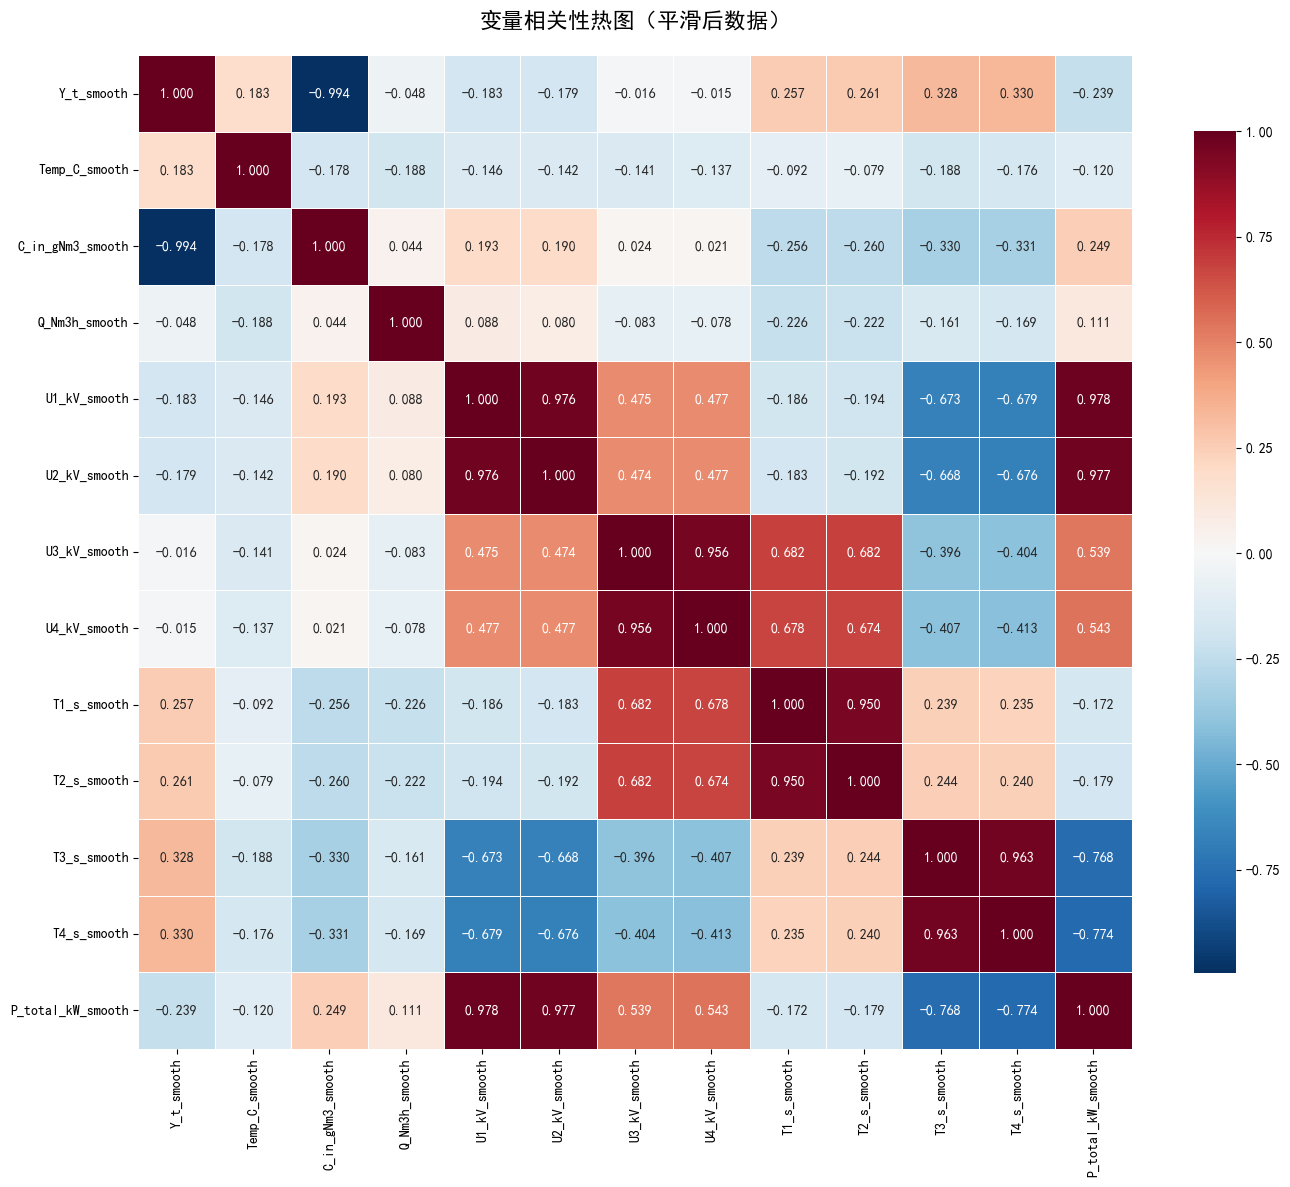

In [7]:
# ============================
# 相关性分析
# ============================
print("\n相关性分析")
print("-" * 50)

corr_vars = [
    "Y_t_smooth",
    "Temp_C_smooth",
    "C_in_gNm3_smooth",
    "Q_Nm3h_smooth",
    "U1_kV_smooth",
    "U2_kV_smooth",
    "U3_kV_smooth",
    "U4_kV_smooth",
    "T1_s_smooth",
    "T2_s_smooth",
    "T3_s_smooth",
    "T4_s_smooth",
    "P_total_kW_smooth",
]

corr_matrix = df_smooth[corr_vars].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("变量相关性热图（平滑后数据）", fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(f"{output_dir}/03_相关性热图.png", dpi=300, bbox_inches="tight")
print(f"已保存: 03_相关性热图.png")

# 输出 Y_t 与各变量的相关系数
y_corr = corr_matrix["Y_t_smooth"].sort_values(ascending=False)
print(f"\nY_t 与各变量的相关系数:")
print(y_corr)


物理机理建模 - 多依奇公式
--------------------------------------------------
参数优化结果:
  最优 d = 0.5000
  最优 k2 = 0.3000
  最优 R2 = 0.1196

物理模型（纯多依奇公式）性能:
  R2 = 0.1196
  RMSE = 0.2447
已保存: 04_物理模型分析.png


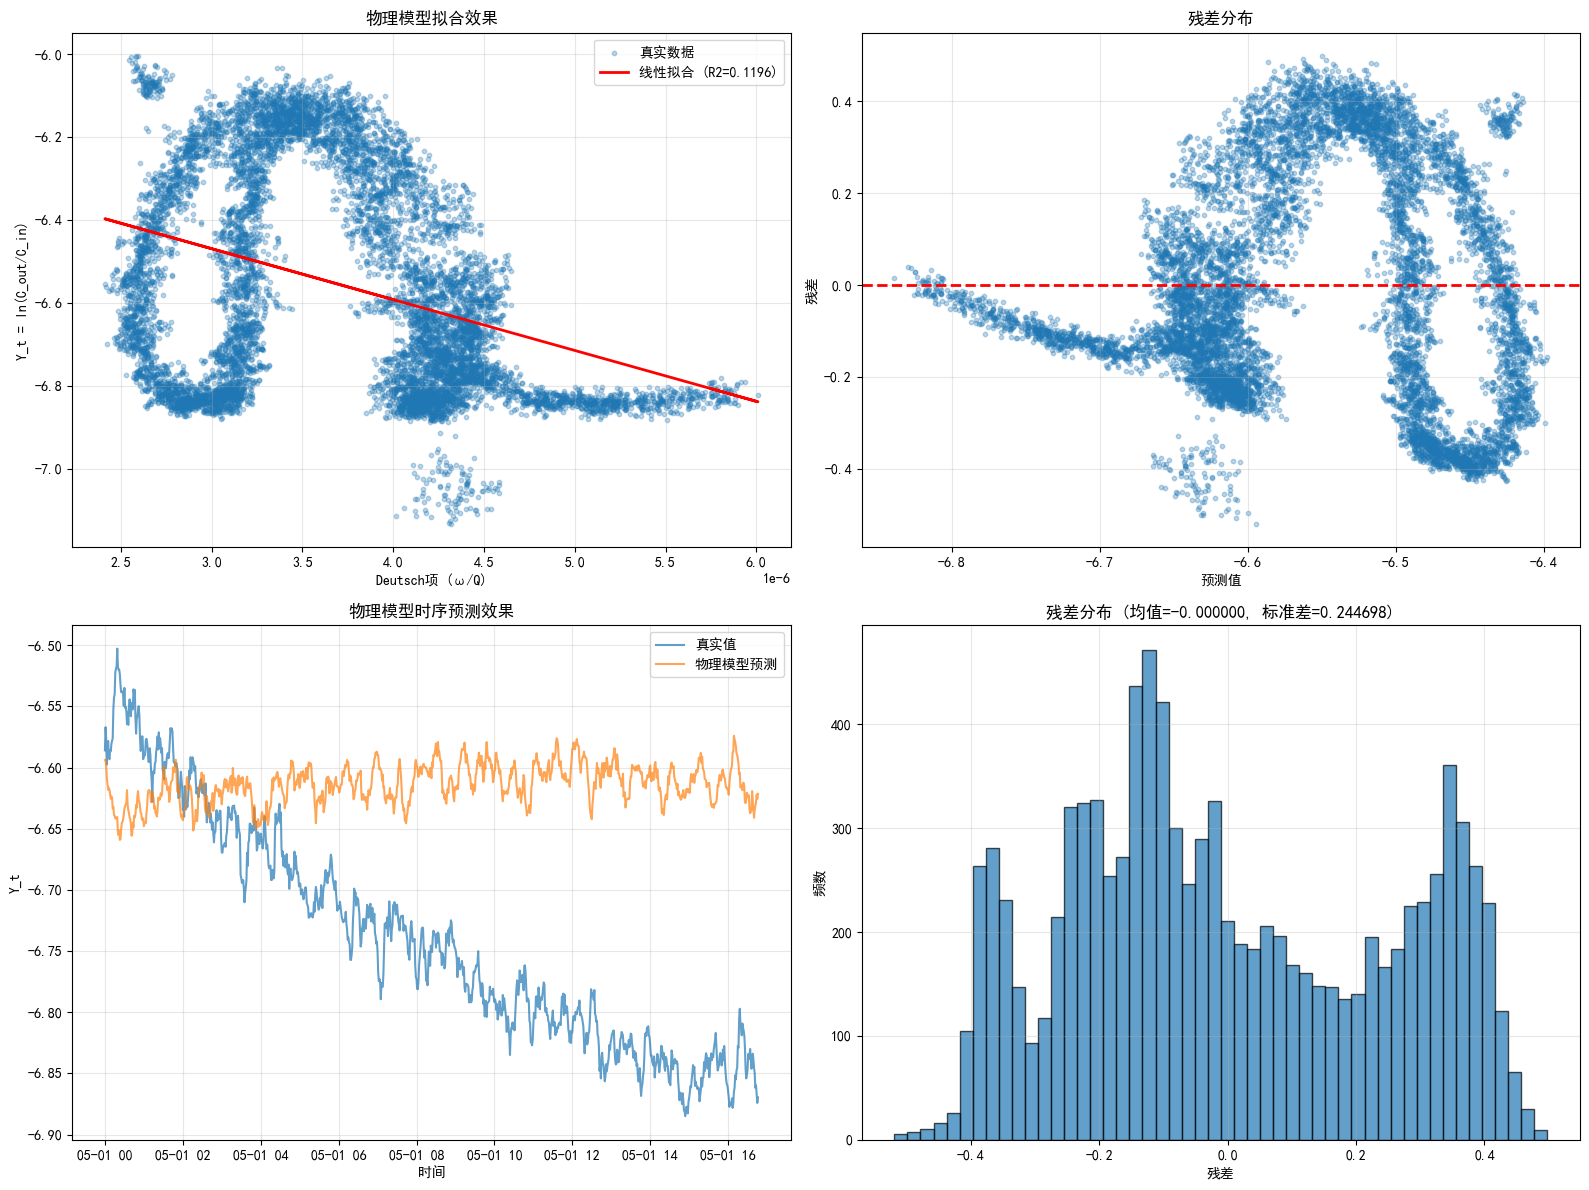

In [8]:
# ============================
# 物理机理建模（多依奇公式）
# ============================
print("\n物理机理建模 - 多依奇公式")
print("-" * 50)

# 参数扫描：寻找最优的物理参数
d_values = np.linspace(0.5, 2.0, 20)
k2_values = np.linspace(0.01, 0.3, 20)

best_r2 = -np.inf
best_d = None
best_k2 = None

for d in d_values:
    for k2 in k2_values:
        # 计算Deutsch项
        omega_total = 0
        for i in range(1, 5):
            omega_i = (
                df_smooth[f"U{i}_kV_smooth"] ** 2
                / (d + k2 * df_smooth[f"T{i}_s_smooth"]) ** 2
            )
            omega_total += omega_i

        deutsch_term = omega_total / df_smooth["Q_Nm3h_smooth"]

        # 计算相关系数
        r2_temp = np.corrcoef(deutsch_term, df_smooth["Y_t_smooth"])[0, 1] ** 2

        if r2_temp > best_r2:
            best_r2 = r2_temp
            best_d = d
            best_k2 = k2

print(f"参数优化结果:")
print(f"  最优 d = {best_d:.4f}")
print(f"  最优 k2 = {best_k2:.4f}")
print(f"  最优 R2 = {best_r2:.4f}")

# 使用最优参数计算
for i in range(1, 5):
    df_smooth[f"omega_{i}"] = (
        df_smooth[f"U{i}_kV_smooth"] ** 2
        / (best_d + best_k2 * df_smooth[f"T{i}_s_smooth"]) ** 2
    )

df_smooth["omega_total"] = (
    df_smooth["omega_1"]
    + df_smooth["omega_2"]
    + df_smooth["omega_3"]
    + df_smooth["omega_4"]
)
df_smooth["Deutsch_term"] = df_smooth["omega_total"] / df_smooth["Q_Nm3h_smooth"]

# 线性回归拟合
X_deutsch = df_smooth["Deutsch_term"].values.reshape(-1, 1)
y_deutsch = df_smooth["Y_t_smooth"].values

lr_model = LinearRegression()
lr_model.fit(X_deutsch, y_deutsch)
y_pred_deutsch = lr_model.predict(X_deutsch)

r2_deutsch = r2_score(y_deutsch, y_pred_deutsch)
rmse_deutsch = np.sqrt(mean_squared_error(y_deutsch, y_pred_deutsch))

print(f"\n物理模型（纯多依奇公式）性能:")
print(f"  R2 = {r2_deutsch:.4f}")
print(f"  RMSE = {rmse_deutsch:.4f}")

# 物理模型拟合效果可视化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 散点图
axes[0, 0].scatter(
    df_smooth["Deutsch_term"],
    df_smooth["Y_t_smooth"],
    alpha=0.3,
    s=10,
    label="真实数据",
)
axes[0, 0].plot(
    df_smooth["Deutsch_term"],
    y_pred_deutsch,
    color="red",
    linewidth=2,
    label=f"线性拟合 (R2={r2_deutsch:.4f})",
)
axes[0, 0].set_xlabel("Deutsch项 (ω/Q)")
axes[0, 0].set_ylabel("Y_t = ln(C_out/C_in)")
axes[0, 0].set_title("物理模型拟合效果")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 残差分析
residuals = y_deutsch - y_pred_deutsch
axes[0, 1].scatter(y_pred_deutsch, residuals, alpha=0.3, s=10)
axes[0, 1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel("预测值")
axes[0, 1].set_ylabel("残差")
axes[0, 1].set_title("残差分布")
axes[0, 1].grid(alpha=0.3)

# 时序拟合对比
sample_range = slice(0, min(1000, len(df_smooth)))
sample_idx = df_smooth.index[sample_range]
axes[1, 0].plot(
    df_smooth.loc[sample_idx, "timestamp"],
    df_smooth.loc[sample_idx, "Y_t_smooth"],
    linewidth=1.5,
    label="真实值",
    alpha=0.7,
)
axes[1, 0].plot(
    df_smooth.loc[sample_idx, "timestamp"],
    y_pred_deutsch[sample_range],
    linewidth=1.5,
    label="物理模型预测",
    alpha=0.7,
)
axes[1, 0].set_ylabel("Y_t")
axes[1, 0].set_xlabel("时间")
axes[1, 0].set_title("物理模型时序预测效果")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 残差直方图
axes[1, 1].hist(residuals, bins=50, edgecolor="black", alpha=0.7)
axes[1, 1].set_xlabel("残差")
axes[1, 1].set_ylabel("频数")
axes[1, 1].set_title(
    f"残差分布 (均值={residuals.mean():.6f}, 标准差={residuals.std():.6f})"
)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/04_物理模型分析.png", dpi=300, bbox_inches="tight")
print(f"已保存: 04_物理模型分析.png")


步骤6: 峰值检测对比（原始数据 vs 平滑数据）
--------------------------------------------------

峰值检测结果对比:
  原始数据峰值数量: 345 (3.44%)
  平滑数据峰值数量: 344 (3.43%)
已保存: 05_峰值检测对比.png


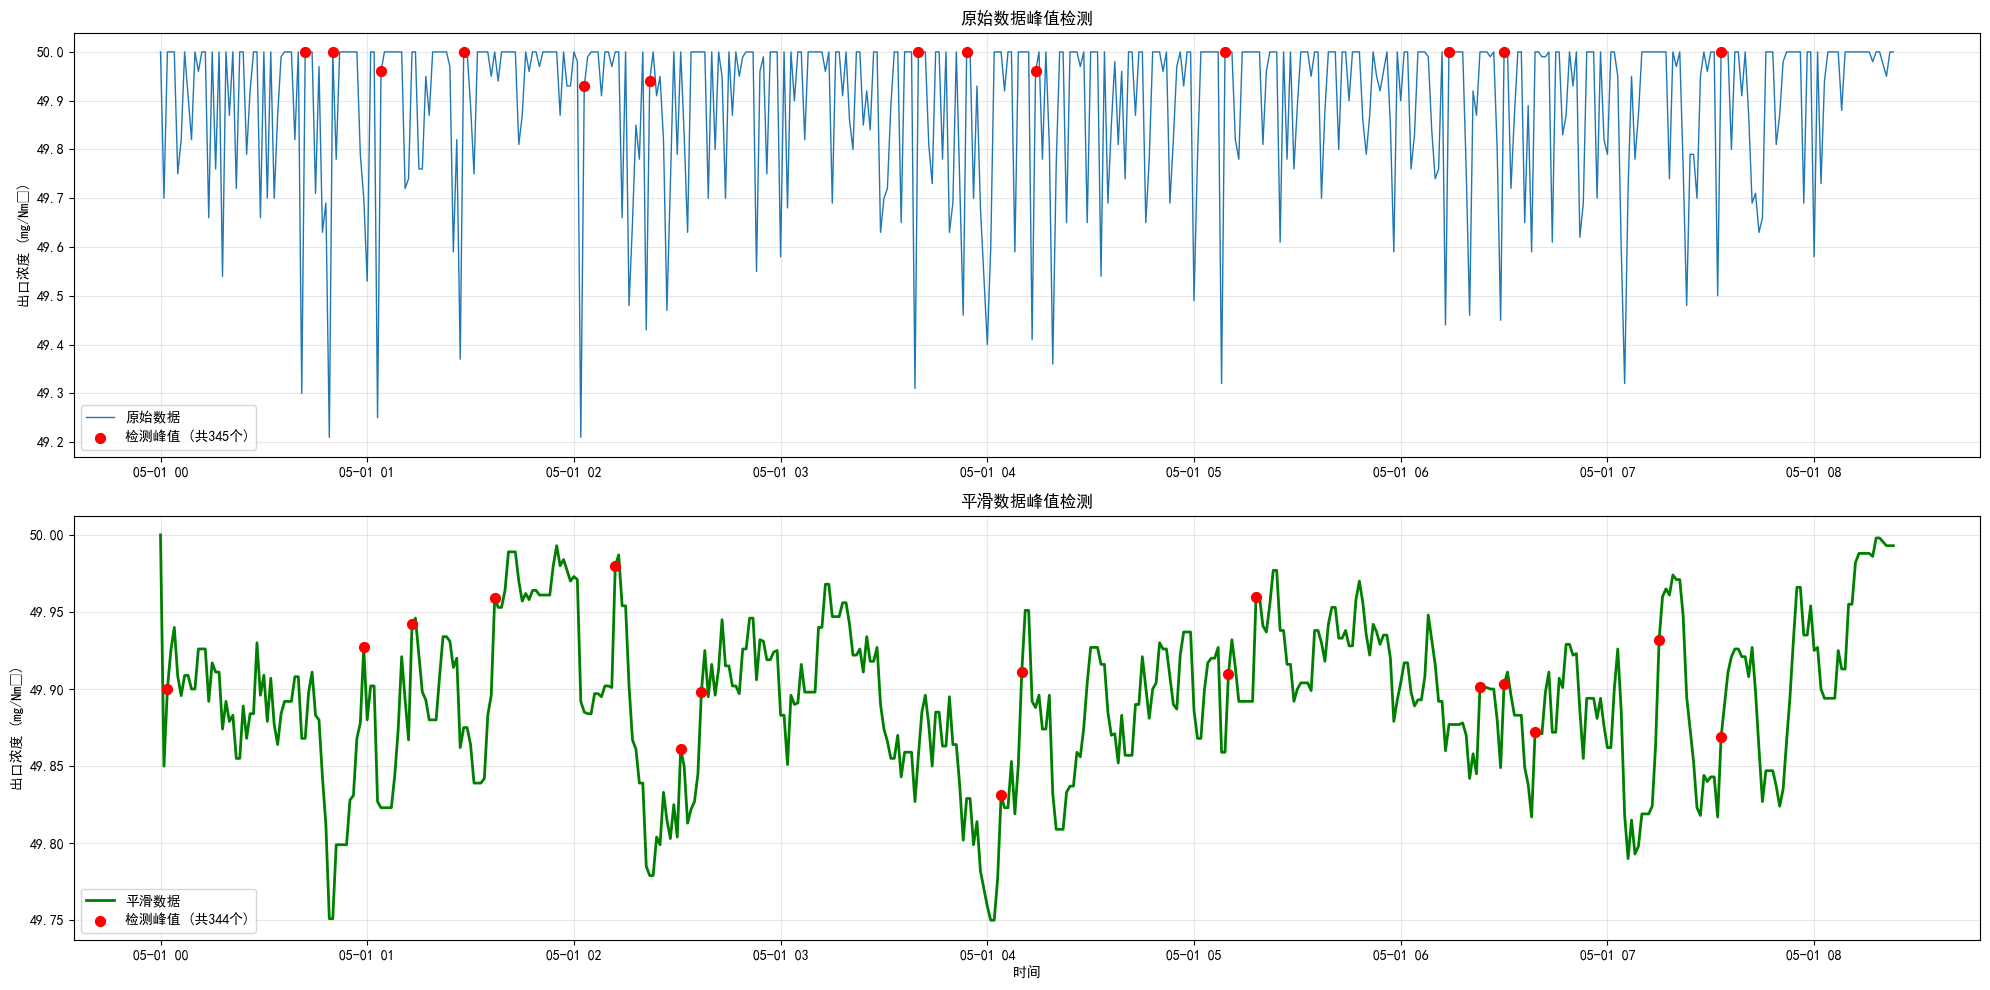

In [9]:
# ============================
# 6. 峰值检测对比（原始 vs 平滑）
# ============================
print("\n步骤6: 峰值检测对比（原始数据 vs 平滑数据）")
print("-" * 50)

# 原始数据峰值检测
df_clean["C_out_diff"] = df_clean["C_out_mgNm3"].diff()
threshold_raw = df_clean["C_out_diff"].std() * 2
df_clean["is_peak"] = (df_clean["C_out_diff"] > threshold_raw).astype(int)
peaks_raw = df_clean[df_clean["is_peak"] == 1]

# 平滑数据峰值检测
df_smooth["C_out_diff_smooth"] = df_smooth["C_out_mgNm3_smooth"].diff()
threshold_smooth = df_smooth["C_out_diff_smooth"].std() * 2
df_smooth["is_peak"] = (df_smooth["C_out_diff_smooth"] > threshold_smooth).astype(int)
peaks_smooth = df_smooth[df_smooth["is_peak"] == 1]

print(f"\n峰值检测结果对比:")
print(f"  原始数据峰值数量: {len(peaks_raw)} ({len(peaks_raw)/len(df_clean)*100:.2f}%)")
print(
    f"  平滑数据峰值数量: {len(peaks_smooth)} ({len(peaks_smooth)/len(df_smooth)*100:.2f}%)"
)

# 可视化对比
fig, axes = plt.subplots(2, 1, figsize=(20, 10))

sample_range = slice(0, 500)

# 原始数据
axes[0].plot(
    df_clean.loc[sample_range, "timestamp"],
    df_clean.loc[sample_range, "C_out_mgNm3"],
    linewidth=1,
    label="原始数据",
)
axes[0].scatter(
    df_clean.loc[sample_range, "timestamp"][df_clean.loc[sample_range, "is_peak"] == 1],
    df_clean.loc[sample_range, "C_out_mgNm3"][
        df_clean.loc[sample_range, "is_peak"] == 1
    ],
    color="red",
    s=50,
    label=f"检测峰值 (共{len(peaks_raw)}个)",
    zorder=5,
)
axes[0].set_ylabel("出口浓度 (mg/Nm³)")
axes[0].set_title("原始数据峰值检测")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 平滑数据
axes[1].plot(
    df_smooth.loc[sample_range, "timestamp"],
    df_smooth.loc[sample_range, "C_out_mgNm3_smooth"],
    linewidth=2,
    label="平滑数据",
    color="green",
)
axes[1].scatter(
    df_smooth.loc[sample_range, "timestamp"][
        df_smooth.loc[sample_range, "is_peak"] == 1
    ],
    df_smooth.loc[sample_range, "C_out_mgNm3_smooth"][
        df_smooth.loc[sample_range, "is_peak"] == 1
    ],
    color="red",
    s=50,
    label=f"检测峰值 (共{len(peaks_smooth)}个)",
    zorder=5,
)
axes[1].set_ylabel("出口浓度 (mg/Nm³)")
axes[1].set_xlabel("时间")
axes[1].set_title("平滑数据峰值检测")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/05_峰值检测对比.png", dpi=300, bbox_inches="tight")
print(f"已保存: 05_峰值检测对比.png")

In [13]:
# ============================
# 7. 构造滞后特征矩阵
# ============================
print("\n步骤7: 构造滞后特征矩阵")
print("-" * 50)

# 构造滞后特征
lag_steps = 3
lag_features = [
    "Temp_C_smooth",
    "C_in_gNm3_smooth",
    "Q_Nm3h_smooth",
    "U1_kV_smooth",
    "U2_kV_smooth",
    "U3_kV_smooth",
    "U4_kV_smooth",
    "T1_s_smooth",
    "T2_s_smooth",
    "T3_s_smooth",
    "T4_s_smooth",
    "Deutsch_term",
]

df_lagged = df_smooth.copy()

for feature in lag_features:
    for lag in range(1, lag_steps + 1):
        df_lagged[f"{feature}_lag{lag}"] = df_lagged[feature].shift(lag)

df_lagged = df_lagged.dropna().reset_index(drop=True)


print(f"滞后特征构造完成，有效样本数: {df_lagged.shape[0]}")


步骤7: 构造滞后特征矩阵
--------------------------------------------------
滞后特征构造完成，有效样本数: 10027


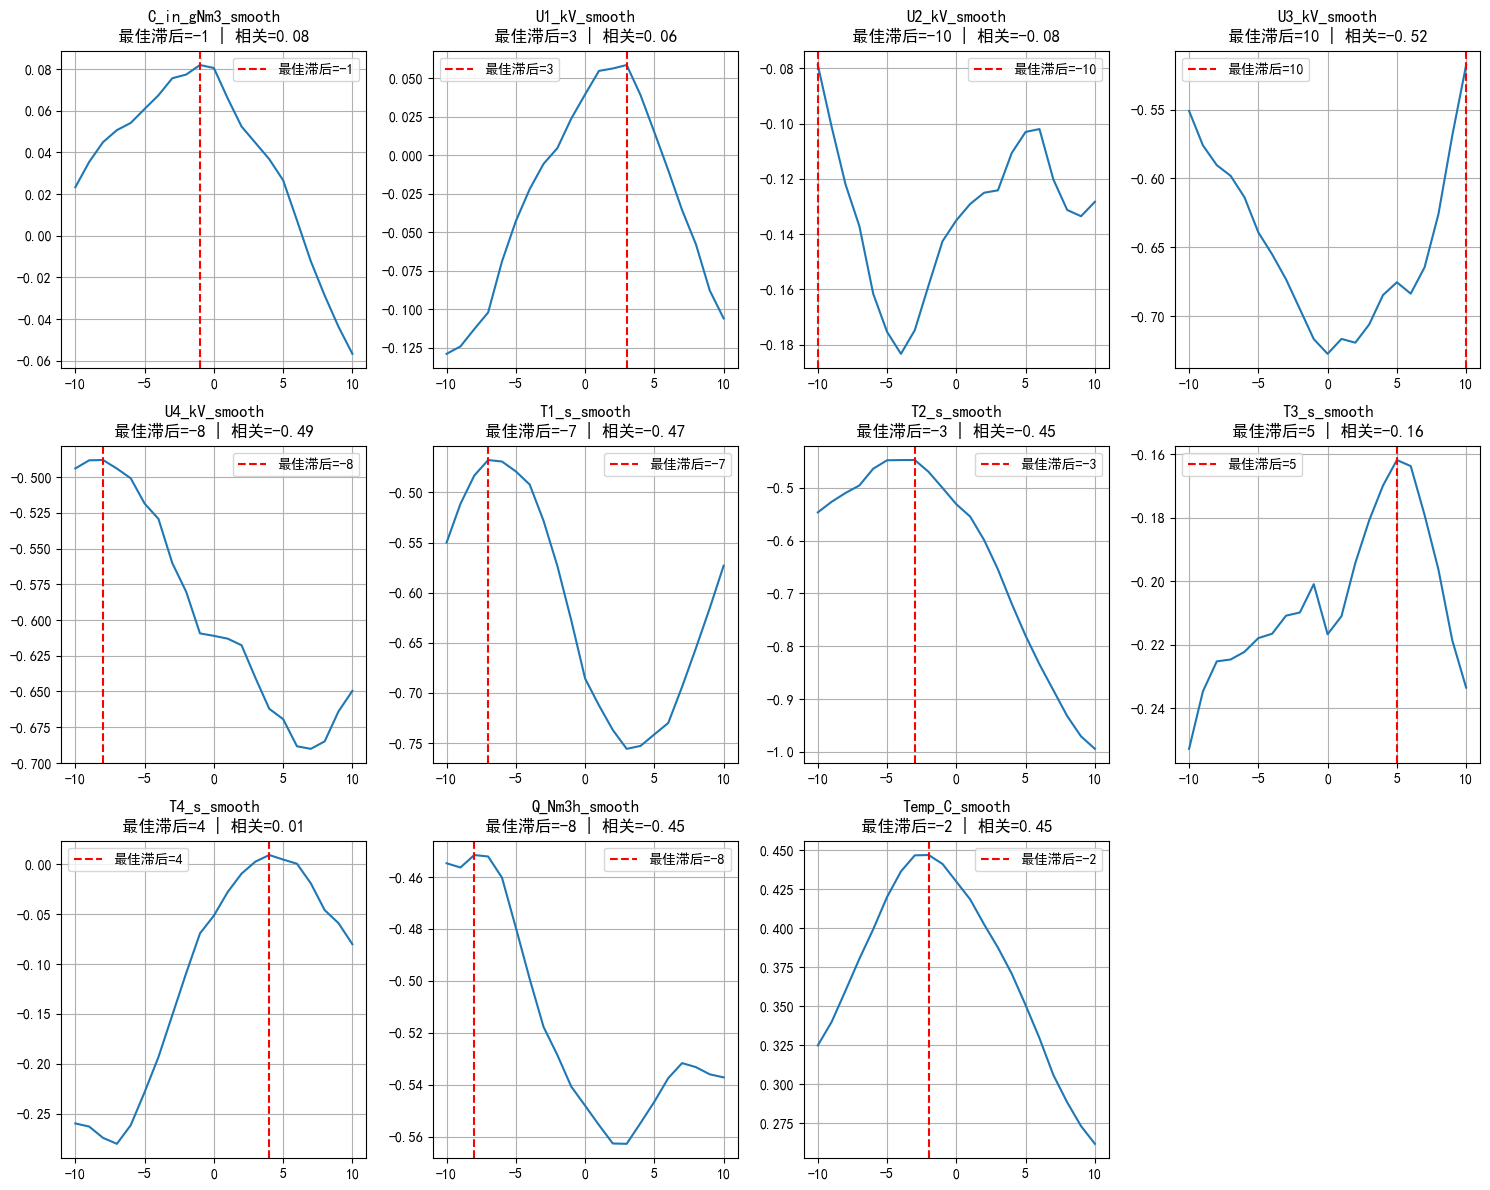

In [14]:
# ============================
# 正确方法：交叉相关分析（看迟滞/滞后关系）
# ============================
import matplotlib.pyplot as plt
from scipy.signal import correlate

# 目标：出口浓度
target = "C_out_mgNm3_smooth"

# 要分析滞后的参数
features = [
    "C_in_gNm3_smooth",
    "U1_kV_smooth",
    "U2_kV_smooth",
    "U3_kV_smooth",
    "U4_kV_smooth",
    "T1_s_smooth",
    "T2_s_smooth",
    "T3_s_smooth",
    "T4_s_smooth",
    "Q_Nm3h_smooth",
    "Temp_C_smooth",
]

max_lag = 10  # 检查前后10分钟的滞后关系

plt.figure(figsize=(15, 12))
for i, feat in enumerate(features):
    # 交叉相关
    x = df_smooth[feat]
    y = df_smooth[target]
    corr = correlate(x - x.mean(), y - y.mean(), mode="full")
    corr /= corr.max() + 1e-6

    lags = np.arange(-max_lag, max_lag + 1)
    mid = len(corr) // 2
    corr_sub = corr[mid - max_lag : mid + max_lag + 1]

    best_lag = lags[np.argmax(corr_sub)]
    best_corr = np.max(corr_sub)

    plt.subplot(3, 4, i + 1)
    plt.plot(lags, corr_sub)
    plt.axvline(x=best_lag, color="r", linestyle="--", label=f"最佳滞后={best_lag}")
    plt.title(f"{feat}\n最佳滞后={best_lag} | 相关={best_corr:.2f}")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ====================================================
# 8. 残差建模 (机理扣除法)
# ====================================================
print("\n步骤8: 正在执行机理残差深度建模...")
print("-" * 50)

df_lagged["Y_t_phys"] = lr_model.predict(
    df_lagged["Deutsch_term"].values.reshape(-1, 1)
)

y_residual = df_lagged["Y_t_smooth"] - df_lagged["Y_t_phys"]

all_potential_features = [
    col for col in df_lagged.columns if "_lag" in col or "Deutsch" in col
]
feature_cols = [
    col
    for col in all_potential_features
    if "C_in" not in col  # 禁入！
    and "C_out" not in col
    and "Y_t" not in col
    and "_lag1" not in col
]

X = df_lagged[feature_cols]

# 4. 划分与训练 (保持 Shuffle=True 确保稳健)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_residual, test_size=0.2, random_state=42, shuffle=True
)

xgb_res = XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05, reg_lambda=5, random_state=42
)
xgb_res.fit(X_train, y_train)

# 5. 组合预测性能评估 (物理 + 残差修正)
y_res_pred = xgb_res.predict(X_test)
y_final_pred = df_lagged.loc[X_test.index, "Y_t_phys"] + y_res_pred
final_r2 = r2_score(df_lagged.loc[X_test.index, "Y_t_smooth"], y_final_pred)

print(f"\n物理+残差融合模型最终 R2: {final_r2:.4f}")

# 6. 特征排名
importance_df = pd.DataFrame(
    {"feature": feature_cols, "importance": xgb_res.feature_importances_}
).sort_values("importance", ascending=False)

print("\n【残差模型特征排名】:")
print(importance_df.head(10).to_string(index=False))

# 8.2 最终性能指标统计 (基于您的 y_final_pred)

print("\n" + "-" * 50)
print("正在执行最终指标校核...")

# 获取测试集的真实值 (Y_t_smooth)
y_true_test = df_lagged.loc[X_test.index, "Y_t_smooth"]

# 计算最终评价指标
test_rmse = np.sqrt(mean_squared_error(y_true_test, y_final_pred))
test_mae = mean_absolute_error(y_true_test, y_final_pred)

print(f"融合模型验证指标:")
print(f"  决定系数 R2: {final_r2:.6f}")
print(f"  均方根误差 RMSE: {test_rmse:.6f}")
print(f"  平均绝对误差 MAE: {test_mae:.6f}")


步骤8: 正在执行机理残差深度建模...
--------------------------------------------------

物理+残差融合模型最终 R2: 0.9661

【残差模型特征排名】:
           feature  importance
 U4_kV_smooth_lag3    0.153259
        U4_kV_lag8    0.123006
 U3_kV_smooth_lag2    0.107153
Temp_C_smooth_lag2    0.085305
 U4_kV_smooth_lag2    0.071427
       Q_Nm3h_lag8    0.060435
 U3_kV_smooth_lag3    0.058504
Temp_C_smooth_lag3    0.055397
Q_Nm3h_smooth_lag3    0.050880
Q_Nm3h_smooth_lag2    0.048181

--------------------------------------------------
正在执行最终指标校核...
融合模型验证指标:
  决定系数 R2: 0.966128
  均方根误差 RMSE: 0.048100
  平均绝对误差 MAE: 0.028921



步骤9: 正在导出论文图表...


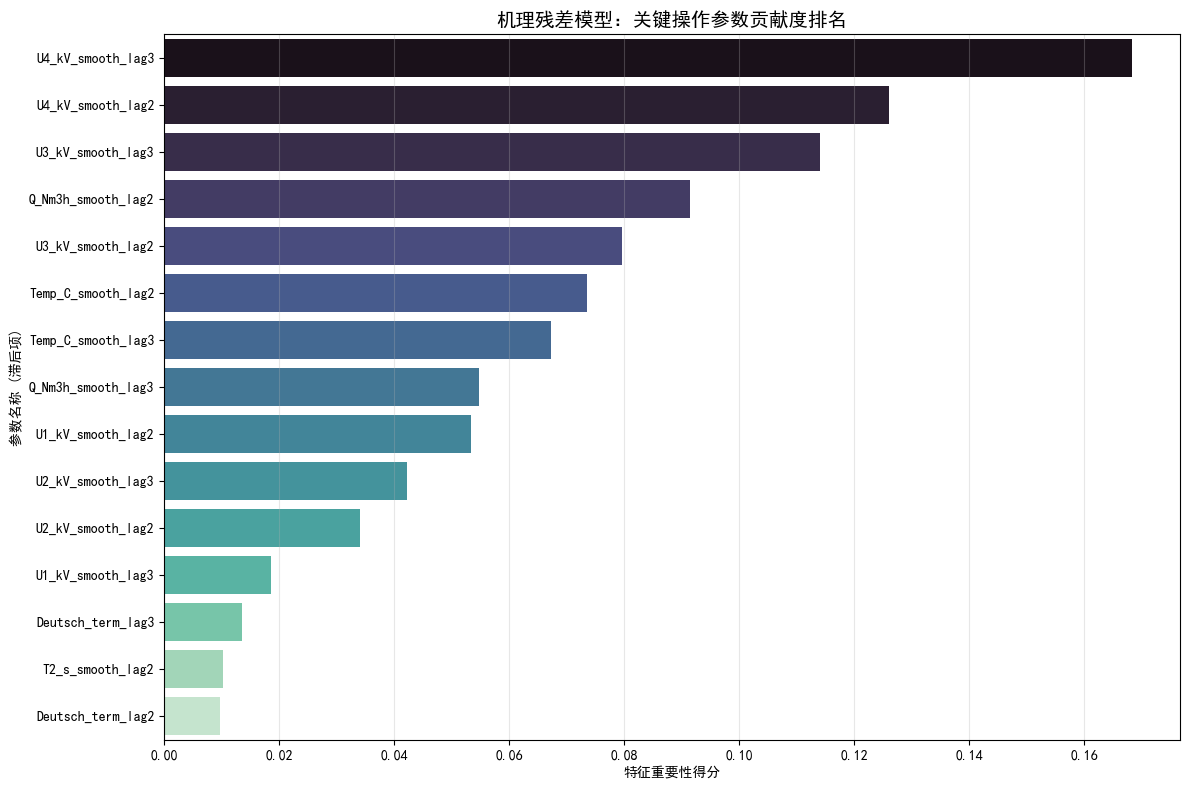

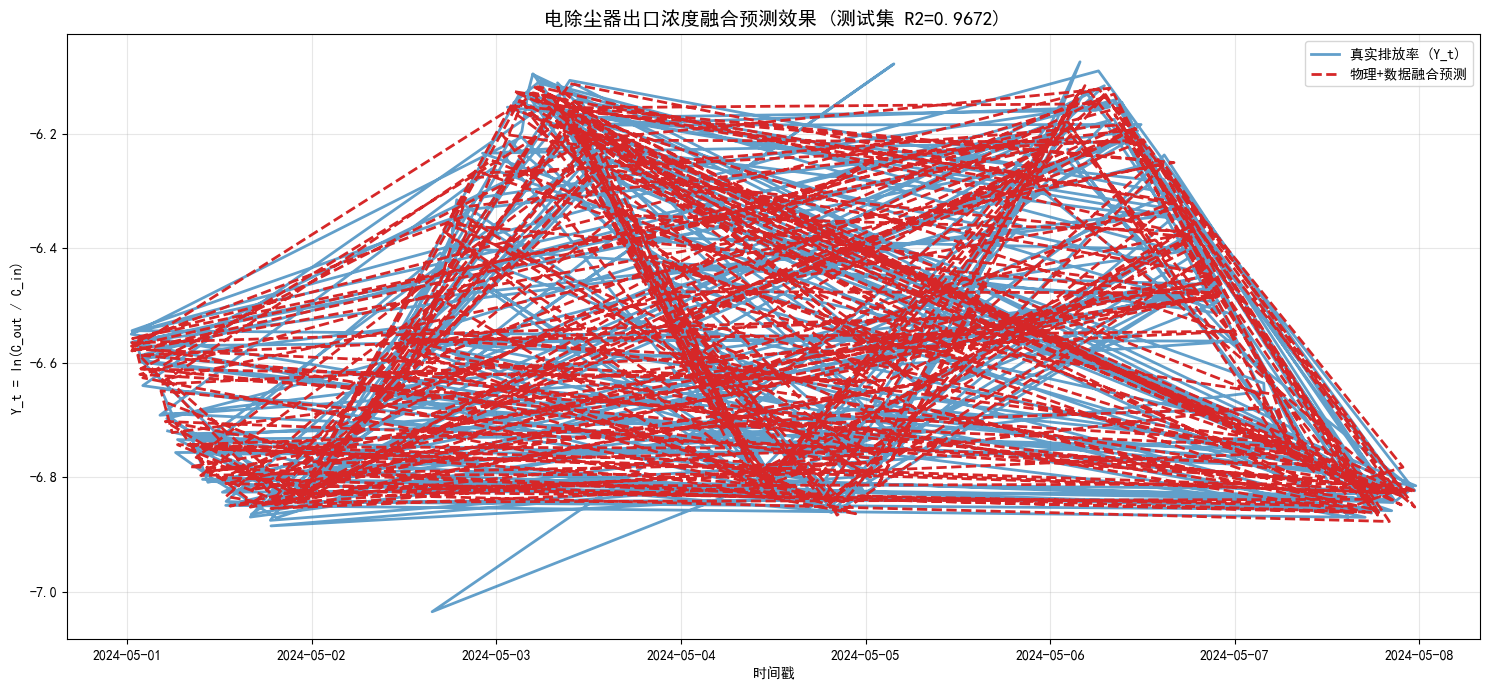

In [11]:
# ============================
# 9. 论文级绘图 (变量名完全适配您的代码)
# ============================
print("\n步骤9: 正在导出论文图表...")

# 图06：残差模型特征重要性 (全是电压和周期！)
plt.figure(figsize=(12, 8))
sns.barplot(x="importance", y="feature", data=importance_df.head(15), palette="mako")
plt.title("机理残差模型：关键操作参数贡献度排名", fontsize=14)
plt.xlabel("特征重要性得分")
plt.ylabel("参数名称 (滞后项)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/06_残差模型特征重要性.png", dpi=300)

# 图07：预测效果实测图
plt.figure(figsize=(15, 7))
# 为了图面清晰，取前300个点进行展示
plot_idx = y_true_test.index[:300]
plt.plot(
    df_lagged.loc[plot_idx, "timestamp"],
    y_true_test.loc[plot_idx],
    label="真实排放率 (Y_t)",
    color="#1f77b4",
    linewidth=2,
    alpha=0.7,
)
plt.plot(
    df_lagged.loc[plot_idx, "timestamp"],
    y_final_pred[:300],
    label="物理+数据融合预测",
    color="#d62728",
    linestyle="--",
    linewidth=2,
)

plt.title(f"电除尘器出口浓度融合预测效果 (测试集 R2={final_r2:.4f})", fontsize=14)
plt.ylabel("Y_t = ln(C_out / C_in)")
plt.xlabel("时间戳")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/07_最终融合预测效果.png", dpi=300)

In [12]:
# ============================
# 10. 保存与收尾
# ============================
# 保存特征排名到CSV
importance_df.to_csv(
    f"{output_dir}/机理残差特征重要性.csv", index=False, encoding="utf-8-sig"
)

# 自动生成结论文字
with open(f"{output_dir}/问题1_最终结论.txt", "w", encoding="utf-8-sig") as f:
    f.write(f"1. 物理机理 R2: {r2_deutsch:.4f}\n")
    f.write(f"2. 融合模型 R2: {final_r2:.4f}\n")
    f.write(
        f"3. 最核心操作因子: {importance_df.iloc[0]['feature']} ({importance_df.iloc[0]['importance']:.4f})\n"
    )


步骤11: 正在补全振打周期对瞬时排放峰值的影响分析...
--------------------------------------------------

峰值时刻振打周期统计:
  T1: 峰值时刻=230.34s, 正常时刻=230.45s, 差异=-0.12s
  T2: 峰值时刻=230.44s, 正常时刻=230.48s, 差异=-0.05s
  T3: 峰值时刻=441.87s, 正常时刻=440.71s, 差异=1.16s
  T4: 峰值时刻=441.68s, 正常时刻=440.70s, 差异=0.98s
已成功补完图表 08 和 09！


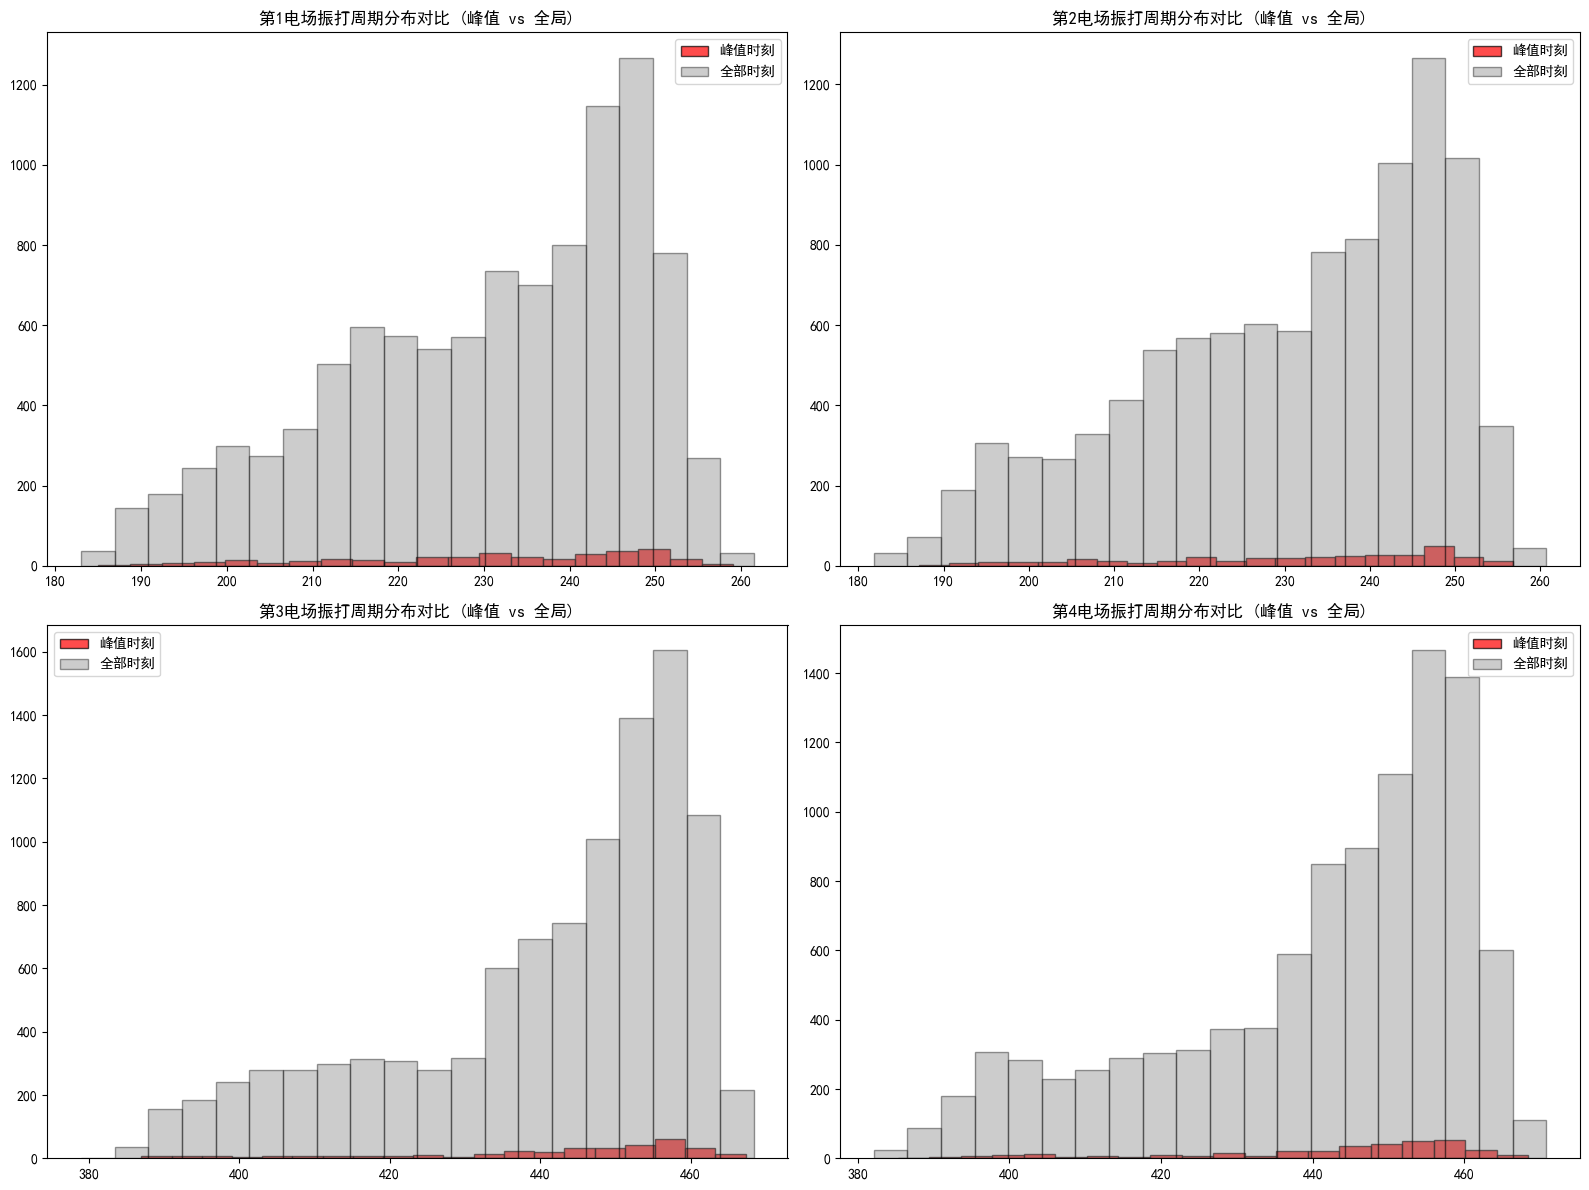

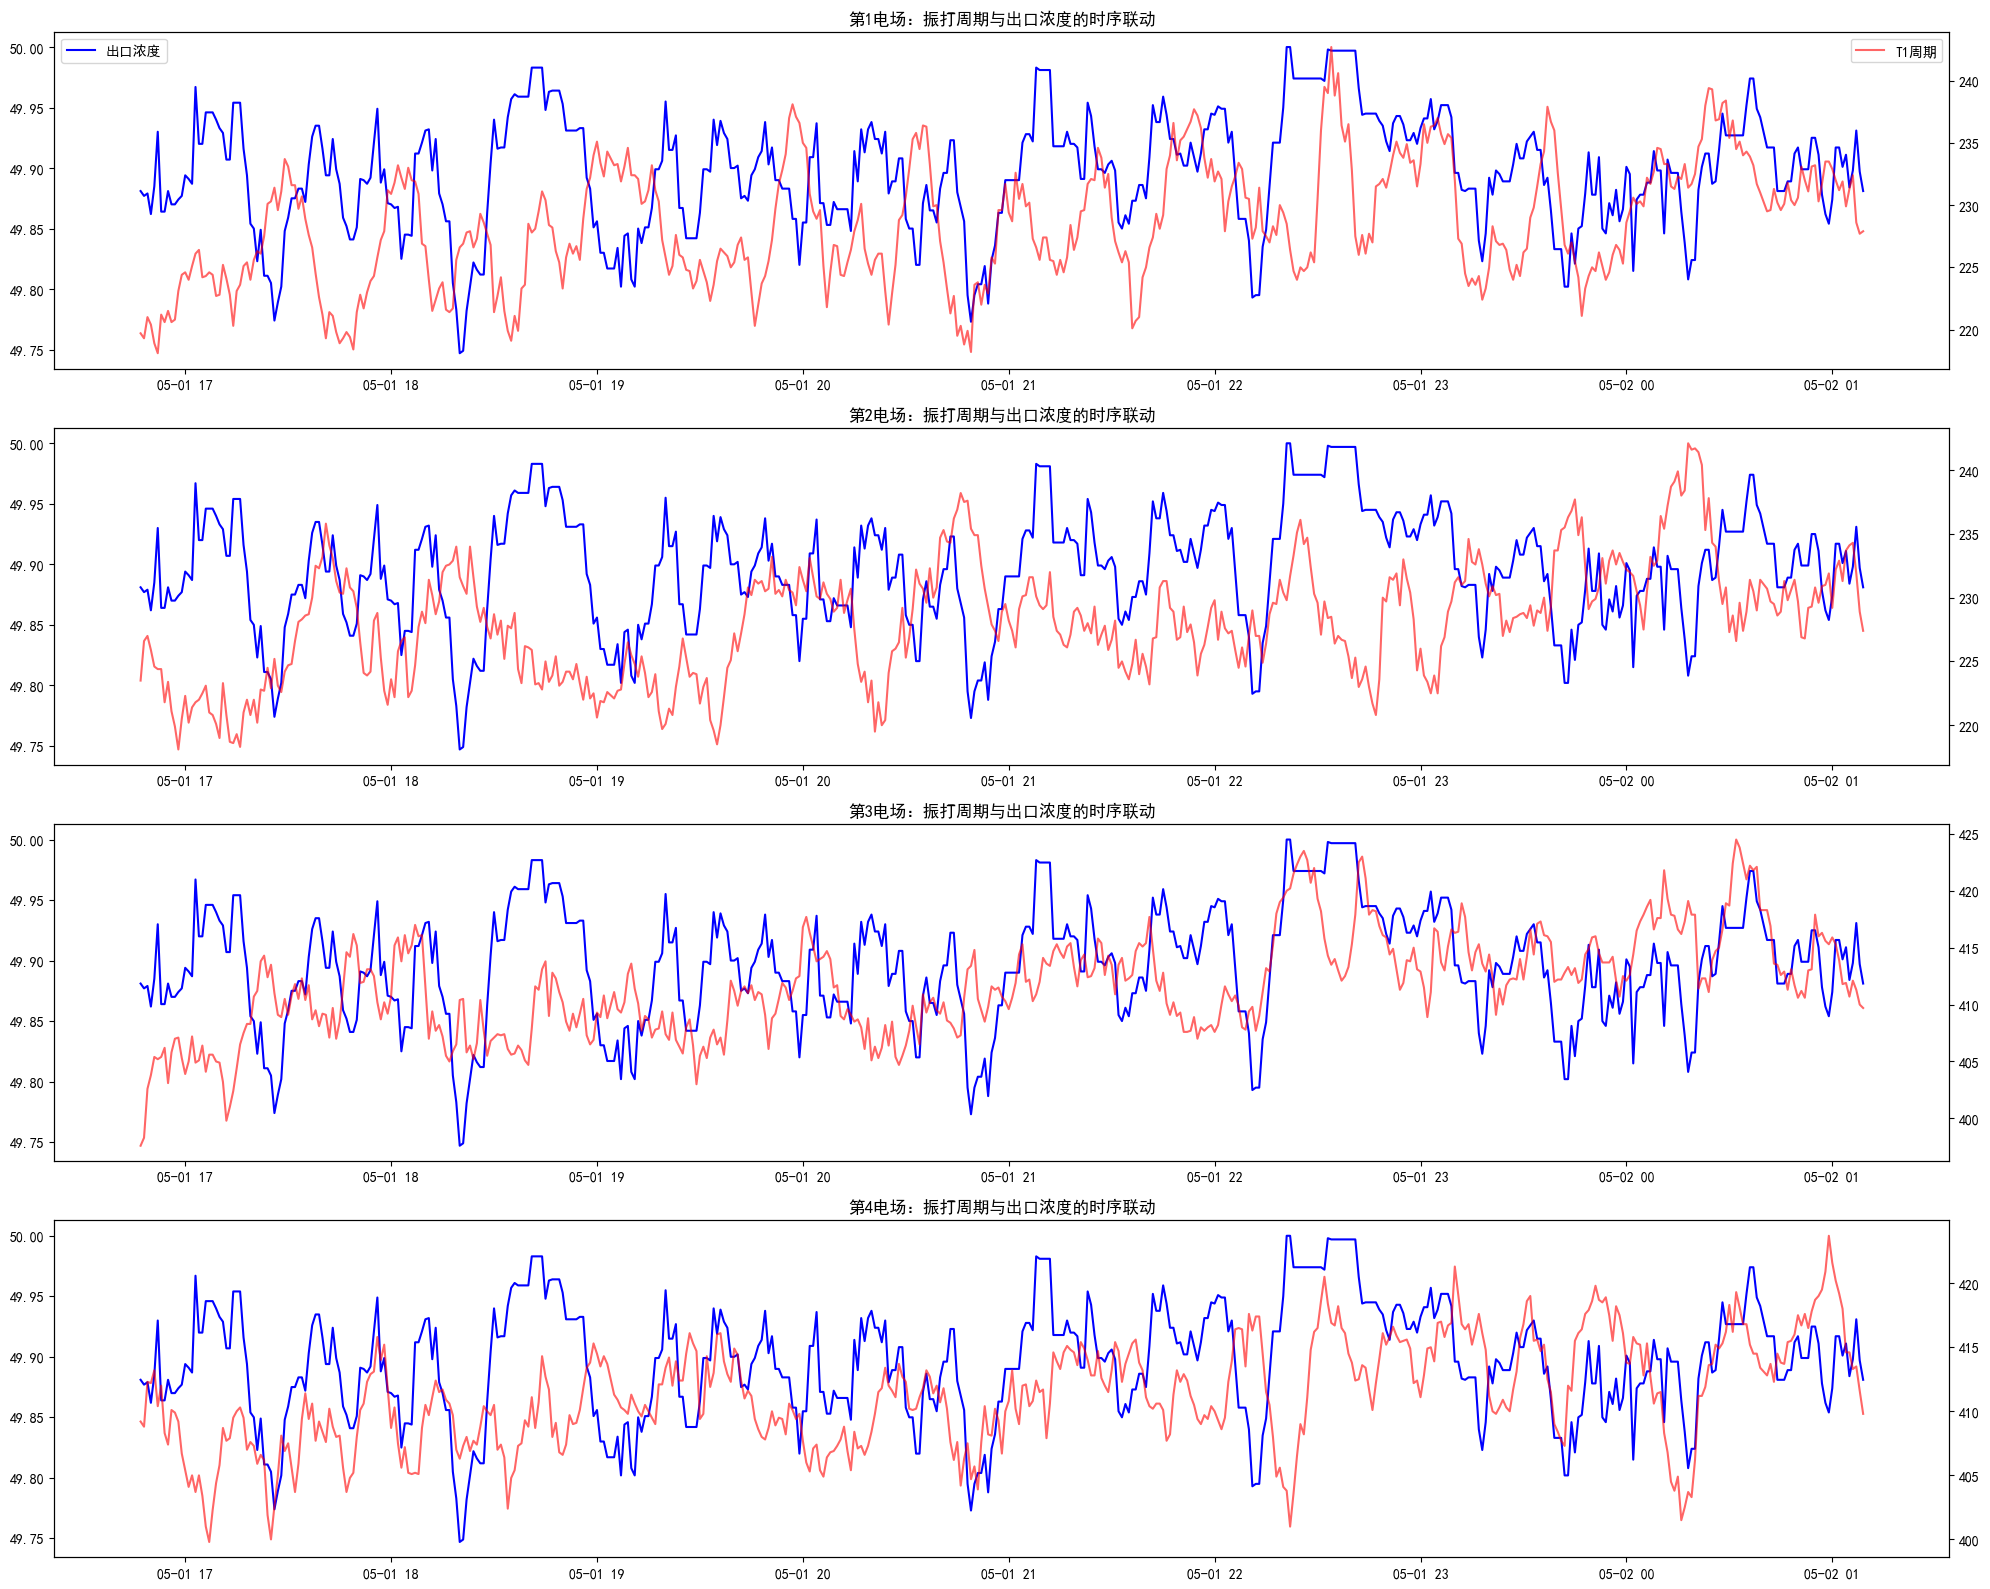

In [13]:
# 11. 振打周期对瞬时排放峰值的影响分析 (补回您之前的精彩分析)
# ====================================================
print("\n步骤11: 正在补全振打周期对瞬时排放峰值的影响分析...")
print("-" * 50)

# 这里确保 peaks_smooth 是存在的（在步骤6中定义的）
if "peaks_smooth" in locals() and len(peaks_smooth) > 0:
    # 统计峰值时刻振打周期的平均值
    print("\n峰值时刻振打周期统计:")
    for i in range(1, 5):
        peak_mean = peaks_smooth[f"T{i}_s_smooth"].mean()
        normal_mean = df_smooth[f"T{i}_s_smooth"].mean()
        print(
            f"  T{i}: 峰值时刻={peak_mean:.2f}s, 正常时刻={normal_mean:.2f}s, 差异={peak_mean-normal_mean:.2f}s"
        )

    # 绘图 08: 振打周期分布对比
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    for i in range(4):
        axes[i // 2, i % 2].hist(
            peaks_smooth[f"T{i+1}_s_smooth"],
            bins=20,
            alpha=0.7,
            label="峰值时刻",
            edgecolor="black",
            color="red",
        )
        axes[i // 2, i % 2].hist(
            df_smooth[f"T{i+1}_s_smooth"],
            bins=20,
            alpha=0.4,
            label="全部时刻",
            edgecolor="black",
            color="gray",
        )
        axes[i // 2, i % 2].set_title(f"第{i+1}电场振打周期分布对比 (峰值 vs 全局)")
        axes[i // 2, i % 2].legend()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/08_振打周期vs排放峰值.png", dpi=300)

    # 绘图 09: 动态关系追踪
    fig, axes = plt.subplots(4, 1, figsize=(20, 16))
    sample_range = slice(1000, 1500)  # 取一段典型数据展示
    for i in range(4):
        ax1 = axes[i]
        ax2 = ax1.twinx()
        ax1.plot(
            df_smooth.loc[sample_range, "timestamp"],
            df_smooth.loc[sample_range, "C_out_mgNm3_smooth"],
            color="blue",
            label="出口浓度",
        )
        ax2.plot(
            df_smooth.loc[sample_range, "timestamp"],
            df_smooth.loc[sample_range, f"T{i+1}_s_smooth"],
            color="red",
            alpha=0.6,
            label=f"T{i+1}周期",
        )
        ax1.set_title(f"第{i+1}电场：振打周期与出口浓度的时序联动")
        if i == 0:
            ax1.legend(loc="upper left")
            ax2.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/09_振打周期动态影响.png", dpi=300)
    print("已成功补完图表 08 和 09！")

In [ ]:
# 1. 确定保存的文件夹（建议和第二问脚本放一起，省得您找路径）
save_path = r"c:\Users\Administrator\Desktop\数模校赛\题目发布\赛题\2026_A题\outputs\xgboost_final_model.pkl"

# 2. 【关键：打包】把两个模型像装箱一样装进一个字典里
# 修改前
model_to_save = {"phys": lr_model, "res": xgb_res}

# 修改后（改成这样）
model_to_save = {
    "phys": lr_model,
    "res": xgb_res,
    "best_d": best_d,  # 必须存！这是物理尺子
    "best_k2": best_k2,  # 必须存！
    "feature_names": feature_cols,  # 顺便存下特征顺序，防止第二问乱序
}

# 3. 动手保存
with open(save_path, "wb") as f:
    pickle.dump(model_to_save, f)

print(f"恭喜！模型已重新打包保存成功。")
print(f"保存位置是：{save_path}")

恭喜！模型已重新打包保存成功。
保存位置是：c:\Users\Administrator\Desktop\数模校赛\题目发布\赛题\2026_A题\outputs\xgboost_final_model.pkl
